# GWAS on Diseased donors — GSA array data

Same analysis as `metric_corr_with_GWAS_only_diseased_XDP.ipynb`, run against the GSA
genotyping-array cohort instead of WGS. The genotype-side prep (donor-ID matching,
kinship pruning, candidate-region extraction/normalization, ancestry PCA) is done by
[`prepare_GSA_for_GWAS.ipynb`](prepare_GSA_for_GWAS.ipynb) — this notebook picks up
from its outputs (`GSA/subset/candidate.norm.bcf`, `GSA/whole_xdp_PCA/PCA.eigenvec`)
and re-runs the same phenotype computation + GWAS regression as the WGS notebook.

trait ~ allele_dosage + d1d1_z2_cov + age (+ PCs)


## Load snRNA-seq data and select cell types

In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
adata = sc.read_h5ad("/home/gdallagl/myworkdir/XDP/data/XDP/SlideTags_dataset/SlideTags_+_NucSeq.h5ad", backed="r")
adata


AnnData object with n_obs × n_vars = 768735 × 35576 backed at '/home/gdallagl/myworkdir/XDP/data/XDP/SlideTags_dataset/SlideTags_+_NucSeq.h5ad'
    obs: 'x', 'y', 'has_spatial', 'pct_intronic', 'Neighborhood_name', 'Class_name', 'Subclass_name', 'Subclass_bootstrapping_probability', 'Subclass_aggregate_probability', 'Group_name', 'Group_bootstrapping_probability', 'Group_aggregate_probability', 'donor_id', 'bcl', 'library', 'library_id', 'Sorted', 'mapping_coupling_for_zoning', 'zone', 'zone_probability', 'mapping_coupling_for_zoning_4_zones', 'zone_4', 'zone_4_probability', 'ct_for_deg', 'is_neuron', 'dataset', 'sample', 'is_Mito_cluster_matrix', 'is_mito_cluster_patch', 'puck', 'region', 'radial_high_mito_patch', 'radial_patch_in_death', 'radial_patch_in_healthy', 'mito_radial_neighborhood', 'original_donor_id', 'sex', 'condition', 'cohort', 'rqs', 'dv200', 'mqs_numerical', 'mqs', 'ph', 'brain_bank', 'year_collected', 'repeat_length', 'repeat_length_notes', 'age_of_onset', 'age_of_de

In [3]:
obs = adata.obs.copy()

# select only nucseq dataset
obs = obs[obs["dataset"] == "nucseq"].copy()

# map cell types
obs["ct"] = obs["ct_for_deg"].map({
    "eMSN_D1D2": "eMSN_D1D2", "Matrix_D1": "Matrix", "Matrix_D2": "Matrix",
    "Patch_D1": "Patch", "Patch_D2": "Patch"
}).fillna(obs["ct_for_deg"])

# select specific cell types
obs = obs[obs["ct_for_deg"].isin(["eMSN_D1D2", "Matrix_D1", "Matrix_D2"])].copy()

obs


,x,y,has_spatial,pct_intronic,Neighborhood_name,Class_name,Subclass_name,Subclass_bootstrapping_probability,Subclass_aggregate_probability,Group_name,...,year_collected,repeat_length,repeat_length_notes,age_of_onset,age_of_death,disease_duration,cap,immediate_cause_of_death,image,ct
44357,NaN,NaN,False,0.729263,Subpallium GABA,CN LGE GABA,STR Hybrid MSN,0.94,0.94,STR D1D2 Hybrid MSN,...,2023,0,NaN,not_applicable,43,not_applicable,0.0,Myocardial Infraction,NaN,eMSN_D1D2
44358,NaN,NaN,False,0.762042,Subpallium GABA,CN LGE GABA,STR D1 MSN,1.00,1.00,STRv D1 MSN,...,2018,41,NaN,41,56,15,615.0,Pnuemonia,NaN,Matrix
44359,NaN,NaN,False,0.785992,Subpallium GABA,CN LGE GABA,STR D1 MSN,1.00,1.00,STRv D1 MSN,...,2020,38,NaN,51,54,3,114.0,Septicemia,NaN,Matrix
44364,NaN,NaN,False,0.763846,Subpallium GABA,CN LGE GABA,STR D1 MSN,1.00,1.00,STRd D1 Matrix MSN,...,2022,0,NaN,not_applicable,66,not_applicable,0.0,Myocardial Infarction O2 - few hrs,NaN,Matrix
44374,NaN,NaN,False,0.737400,Subpallium GABA,CN LGE GABA,STR Hybrid MSN,0.85,0.85,STR D1D2 Hybrid MSN,...,2023,0,NaN,not_applicable,43,not_applicable,0.0,Myocardial Infraction,NaN,eMSN_D1D2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99434,NaN,NaN,False,0.734533,Subpallium GABA,CN LGE GABA,STR Hybrid MSN,1.00,1.00,STR D1D2 Hybrid MSN,...,2022,46,NaN,NaN,46,NaN,NaN,Acute Respiratory Failure,NaN,eMSN_D1D2
99471,NaN,NaN,False,0.722178,Subpallium GABA,CN LGE GABA,STR Hybrid MSN,1.00,1.00,STR D1D2 Hybrid MSN,...,2023,41,NaN,39,49,10,410.0,Acute Respiratory Macular Paralysis,NaN,eMSN_D1D2
99503,NaN,NaN,False,0.795778,Subpallium GABA,CN LGE GABA,STR Hybrid MSN,1.00,1.00,STRv D1 NUDAP MSN,...,2022,46,NaN,NaN,46,NaN,NaN,Acute Respiratory Failure,NaN,eMSN_D1D2
99517,NaN,NaN,False,0.784605,Subpallium GABA,CN LGE GABA,STR Hybrid MSN,1.00,1.00,STR D1D2 Hybrid MSN,...,2019,43,NaN,36,51,15,645.0,Dystonia,NaN,eMSN_D1D2


## Build per-donor metadata table

In [4]:
# one row per donor
df_meta = obs.drop_duplicates(subset=["donor_id"], keep="first")

df_meta = df_meta[[
       'original_donor_id', 'sex', 'condition', 'cohort', 'rqs', 'dv200',
       'mqs_numerical', 'mqs', 'ph', 'brain_bank', 'year_collected',
       'repeat_length', 'repeat_length_notes', 'age_of_onset', 'age_of_death',
       'disease_duration', 'cap', 'immediate_cause_of_death', 'donor_id']]

df_meta.set_index("donor_id", inplace=True)
df_meta["donor_id"] = df_meta.index

df_meta["m1_z1_raw_trait"] = np.nan
df_meta["m1_z1_trait"] = np.nan
df_meta["d1d1_z2_cov"] = np.nan

donors_from_adata_nucseq = adata[adata.obs["dataset"] == "nucseq"].obs["original_donor_id"].unique().tolist()
print(donors_from_adata_nucseq)
print(len(donors_from_adata_nucseq))

df_meta


['SCF-20-025', 'SCF-22-054CM', 'SCF-19-009', 'SCF-18-006', 'SCF_20-024', 'SCF_22-043', 'SCF-18-003', 'SCF-19-018', 'SCF-19-014', 'SCF-21-030', 'PCMC-16-011', 'SCF-22-058CF', 'SCF-18-004', 'SCF-20-023', 'SCF_21-037CM2', 'SCF-23-068CM', 'PCMC-16-012', 'SCF_23_070_MMC', 'SCF_21_027', 'SCF_21_038', 'SCF_21_029', 'SCF_21_032', 'SCF_22_049CCF', 'SCF_22_063CM', 'SCF_23_074CF', 'SCF_21_041', 'SCF_21_034', 'SCF_22_067CM', 'SCF_23_079CF', 'SCF_22_065CM', 'SCF_23_075CM', 'SCF_23_072CF', 'SCF_22-050CM6', 'SCF_22-048', 'SCF_20-026', 'SCF_22-046CF', 'SCF_22-057CM', 'SCF_22-056CF', 'SCF-22-045', 'SCF_23-081CM', 'SCF-22-044', 'SCF-19-020', 'SCF-22-042', 'SCF_22-052', 'SCF_23-083', 'SCF_22-060', 'SCF_23-080']
47


,original_donor_id,sex,condition,cohort,rqs,dv200,mqs_numerical,mqs,ph,brain_bank,...,repeat_length_notes,age_of_onset,age_of_death,disease_duration,cap,immediate_cause_of_death,donor_id,m1_z1_raw_trait,m1_z1_trait,d1d1_z2_cov
donor_id,,,,,,,,,,,,,,,,,,,,,
SCF-23-068,SCF-23-068CM,M,Control,C_1,6.30,0.76,4.0,B,6.0,SCF,...,NaN,not_applicable,43,not_applicable,0.0,Myocardial Infraction,SCF-23-068,NaN,NaN,NaN
SCF-18-004,SCF-18-004,M,XDP,C_1,6.97,0.78,4.5,AB,6.0,SCF,...,NaN,41,56,15,615.0,Pnuemonia,SCF-18-004,NaN,NaN,NaN
SCF-20-025,SCF-20-025,M,XDP,C_1,6.50,0.74,5.0,A,6.0,SCF,...,NaN,51,54,3,114.0,Septicemia,SCF-20-025,NaN,NaN,NaN
SCF-22-058,SCF-22-058CF,F,Control,C_1,5.79,0.72,2.0,D Redo,6.0,SCF,...,NaN,not_applicable,66,not_applicable,0.0,Myocardial Infarction O2 - few hrs,SCF-22-058,NaN,NaN,NaN
SCF-21-030,SCF-21-030,M,XDP,C_1,6.74,0.80,5.0,A,6.2,SCF,...,NaN,30,43,13,598.0,Myocardial Infraction,SCF-21-030,NaN,NaN,NaN
SCF-18-003,SCF-18-003,M,XDP,C_1,6.92,0.79,5.0,A,6.4,SCF,...,NaN,32,41,9,378.0,"Pnuemonia, Dystonia",SCF-18-003,NaN,NaN,NaN
SCF-20-023,SCF-20-023,M,XDP,C_1,6.71,0.81,5.0,A,6.0,SCF,...,"42, 46 (mosaic)",38,41,3,132.0,Myocardial Infraction,SCF-20-023,NaN,NaN,NaN
SCF-19-009,SCF-19-009,M,XDP,C_1,5.34,0.72,4.5,AB,6.0,SCF,...,NaN,49,54,5,195.0,Pnuemonia,SCF-19-009,NaN,NaN,NaN
SCF-20-024,SCF_20-024,M,XDP,C_1,7.21,0.85,4.0,B,NaN,SCF,...,NaN,39,46,7,322.0,Probable Myocardial Infarction,SCF-20-024,NaN,NaN,NaN


## Calculate trait

In [5]:
from scipy.stats import norm

def rint(series):
    """Rank-based inverse-normal transform (Blom), NaN-safe."""
    x = series.copy()
    mask = x.notna()
    ranks = x[mask].rank(method="average")
    n = mask.sum()
    x[mask] = norm.ppf((ranks - 3/8) / (n - 2*3/8 + 1))
    return x

for donor in df_meta["donor_id"].unique():
    obs_donor = obs[obs["donor_id"] == donor]

    n_m1_total = len(obs_donor[obs_donor["ct_for_deg"] == "Matrix_D1"])
    n_m1_z1    = len(obs_donor[(obs_donor["ct_for_deg"] == "Matrix_D1") & (obs_donor["zone"] == "1")])

    n_espn_total = len(obs_donor[obs_donor["ct_for_deg"] == "eMSN_D1D2"])
    n_espn_z2    = len(obs_donor[(obs_donor["ct_for_deg"] == "eMSN_D1D2") & (obs_donor["zone_4"] == "2")])

    df_meta.loc[donor, "n_m1_total"]      = n_m1_total
    df_meta.loc[donor, "m1_z1_raw_trait"] = n_m1_z1 / n_m1_total if n_m1_total > 0 else np.nan
    df_meta.loc[donor, "d1d1_z2_cov"]     = n_espn_z2 / n_espn_total if n_espn_total > 0 else np.nan

df_meta["m1_z1_trait"] = rint(df_meta["m1_z1_raw_trait"])

df_meta


,original_donor_id,sex,condition,cohort,rqs,dv200,mqs_numerical,mqs,ph,brain_bank,...,age_of_onset,age_of_death,disease_duration,cap,immediate_cause_of_death,donor_id,m1_z1_raw_trait,m1_z1_trait,d1d1_z2_cov,n_m1_total
donor_id,,,,,,,,,,,,,,,,,,,,,
SCF-23-068,SCF-23-068CM,M,Control,C_1,6.30,0.76,4.0,B,6.0,SCF,...,not_applicable,43,not_applicable,0.0,Myocardial Infraction,SCF-23-068,0.147668,0.828465,0.402778,386.0
SCF-18-004,SCF-18-004,M,XDP,C_1,6.97,0.78,4.5,AB,6.0,SCF,...,41,56,15,615.0,Pnuemonia,SCF-18-004,0.000000,-0.946457,0.108108,41.0
SCF-20-025,SCF-20-025,M,XDP,C_1,6.50,0.74,5.0,A,6.0,SCF,...,51,54,3,114.0,Septicemia,SCF-20-025,0.013550,-0.106301,0.244755,369.0
SCF-22-058,SCF-22-058CF,F,Control,C_1,5.79,0.72,2.0,D Redo,6.0,SCF,...,not_applicable,66,not_applicable,0.0,Myocardial Infarction O2 - few hrs,SCF-22-058,0.136268,0.687031,0.371429,477.0
SCF-21-030,SCF-21-030,M,XDP,C_1,6.74,0.80,5.0,A,6.2,SCF,...,30,43,13,598.0,Myocardial Infraction,SCF-21-030,0.030303,0.026528,0.298246,66.0
SCF-18-003,SCF-18-003,M,XDP,C_1,6.92,0.79,5.0,A,6.4,SCF,...,32,41,9,378.0,"Pnuemonia, Dystonia",SCF-18-003,0.000000,-0.946457,0.230769,164.0
SCF-20-023,SCF-20-023,M,XDP,C_1,6.71,0.81,5.0,A,6.0,SCF,...,38,41,3,132.0,Myocardial Infraction,SCF-20-023,0.031250,0.106301,0.307692,160.0
SCF-19-009,SCF-19-009,M,XDP,C_1,5.34,0.72,4.5,AB,6.0,SCF,...,49,54,5,195.0,Pnuemonia,SCF-19-009,0.029197,-0.053075,0.298246,137.0
SCF-20-024,SCF_20-024,M,XDP,C_1,7.21,0.85,4.0,B,NaN,SCF,...,39,46,7,322.0,Probable Myocardial Infarction,SCF-20-024,0.003676,-0.380326,0.144444,272.0


### Analyse

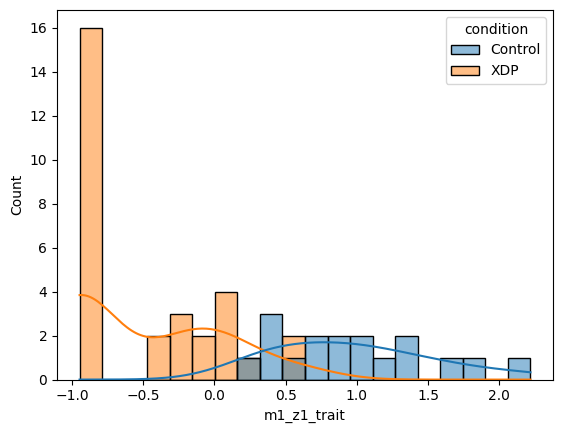

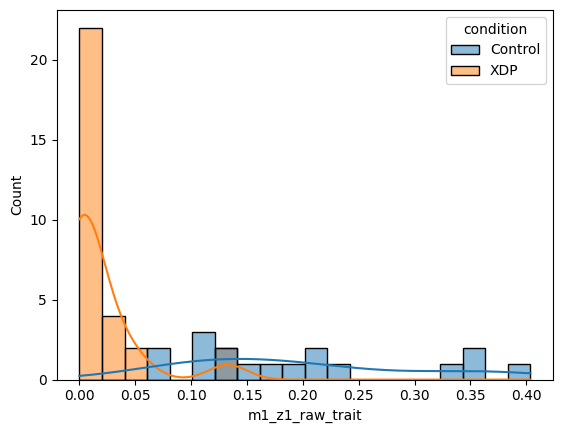

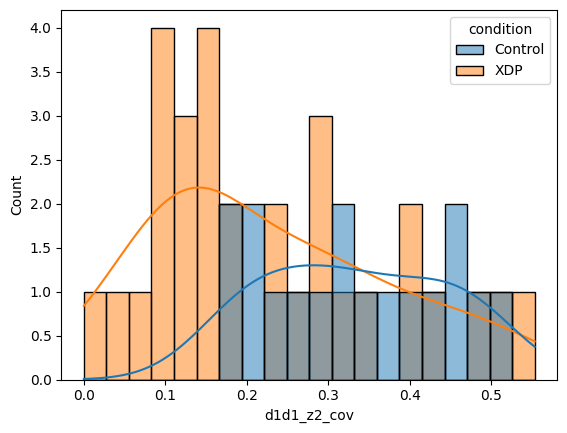

In [6]:
sns.histplot(data=df_meta, x="m1_z1_trait", bins=20, kde=True, hue="condition"); plt.show()
sns.histplot(data=df_meta, x="m1_z1_raw_trait", bins=20, kde=True, hue="condition"); plt.show()
sns.histplot(data=df_meta, x="d1d1_z2_cov", bins=20, kde=True, hue="condition"); plt.show()


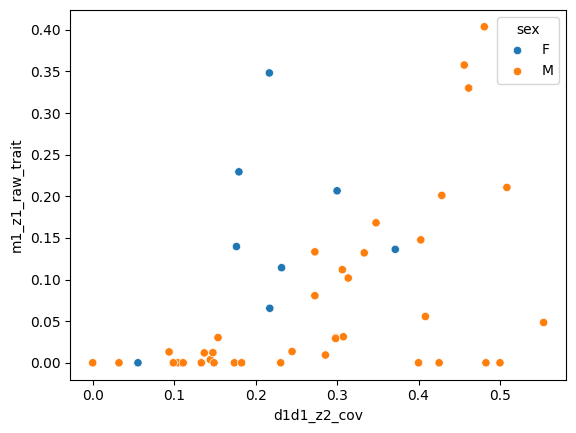

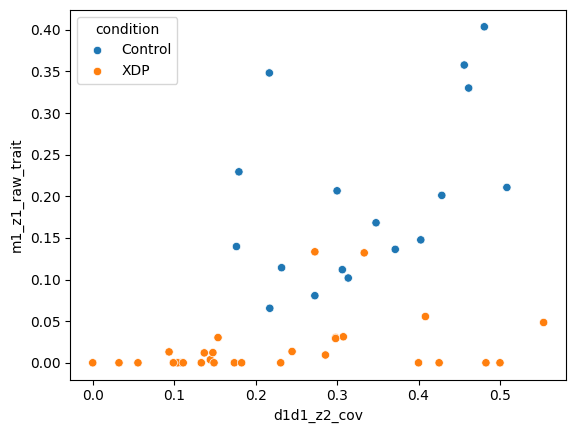

In [7]:
sns.scatterplot(data=df_meta, x="d1d1_z2_cov", y="m1_z1_raw_trait", hue="sex"); plt.show()
sns.scatterplot(data=df_meta, x="d1d1_z2_cov", y="m1_z1_raw_trait", hue="condition"); plt.show()


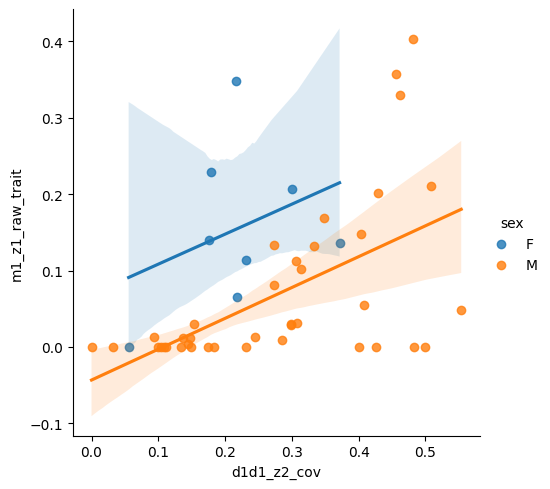

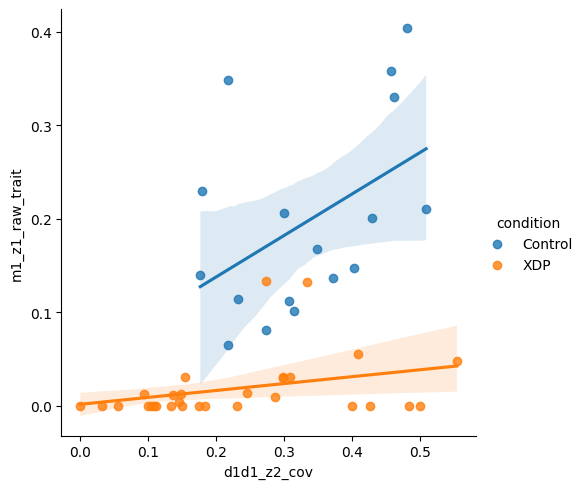

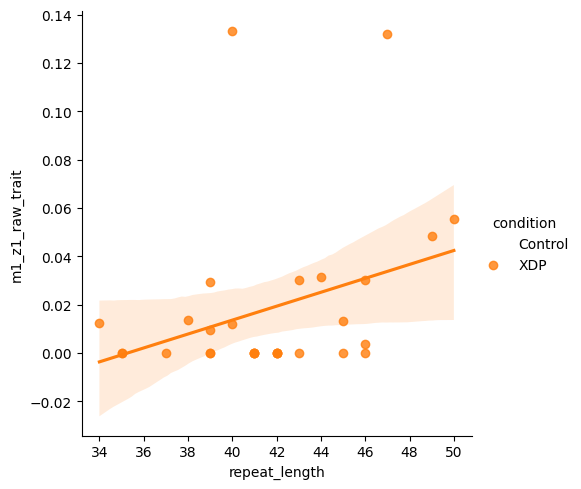

In [8]:
sns.lmplot(data=df_meta, x="d1d1_z2_cov", y="m1_z1_raw_trait", hue="sex"); plt.show()
sns.lmplot(data=df_meta, x="d1d1_z2_cov", y="m1_z1_raw_trait", hue="condition"); plt.show()
sns.lmplot(data=df_meta[df_meta["condition"] == "XDP"], x="repeat_length", y="m1_z1_raw_trait", hue="condition"); plt.show()


### Filter to Diseased + Male donors for GWAS

In [9]:
df_meta_diseased = df_meta[
        (df_meta["condition"] == "XDP") &
        (df_meta["sex"] == "M")
        ].copy()

display(df_meta_diseased)

for var in ["age_of_onset", "age_of_death", "disease_duration", "repeat_length"]:
    numeric_var = pd.to_numeric(df_meta_diseased[var], errors="coerce")
    corr = df_meta_diseased["m1_z1_trait"].corr(numeric_var, method="spearman")
    print(f"Correlation between m1_z1_trait and {var}: {corr:.4f}")

donors_from_adata_nucseq_male_diseased = adata[
    (adata.obs["dataset"] == "nucseq") &
    (adata.obs["condition"] == "XDP") &
    (adata.obs["sex"] == "M")
].obs["original_donor_id"].unique().tolist()
print(donors_from_adata_nucseq_male_diseased)


,original_donor_id,sex,condition,cohort,rqs,dv200,mqs_numerical,mqs,ph,brain_bank,...,age_of_onset,age_of_death,disease_duration,cap,immediate_cause_of_death,donor_id,m1_z1_raw_trait,m1_z1_trait,d1d1_z2_cov,n_m1_total
donor_id,,,,,,,,,,,,,,,,,,,,,
SCF-18-004,SCF-18-004,M,XDP,C_1,6.97,0.78,4.5,AB,6.0,SCF,...,41,56,15,615.0,Pnuemonia,SCF-18-004,0.000000,-0.946457,0.108108,41.0
SCF-20-025,SCF-20-025,M,XDP,C_1,6.50,0.74,5.0,A,6.0,SCF,...,51,54,3,114.0,Septicemia,SCF-20-025,0.013550,-0.106301,0.244755,369.0
SCF-21-030,SCF-21-030,M,XDP,C_1,6.74,0.80,5.0,A,6.2,SCF,...,30,43,13,598.0,Myocardial Infraction,SCF-21-030,0.030303,0.026528,0.298246,66.0
SCF-18-003,SCF-18-003,M,XDP,C_1,6.92,0.79,5.0,A,6.4,SCF,...,32,41,9,378.0,"Pnuemonia, Dystonia",SCF-18-003,0.000000,-0.946457,0.230769,164.0
SCF-20-023,SCF-20-023,M,XDP,C_1,6.71,0.81,5.0,A,6.0,SCF,...,38,41,3,132.0,Myocardial Infraction,SCF-20-023,0.031250,0.106301,0.307692,160.0
SCF-19-009,SCF-19-009,M,XDP,C_1,5.34,0.72,4.5,AB,6.0,SCF,...,49,54,5,195.0,Pnuemonia,SCF-19-009,0.029197,-0.053075,0.298246,137.0
SCF-20-024,SCF_20-024,M,XDP,C_1,7.21,0.85,4.0,B,NaN,SCF,...,39,46,7,322.0,Probable Myocardial Infarction,SCF-20-024,0.003676,-0.380326,0.144444,272.0
SCF-22-043,SCF_22-043,M,XDP,C_1,6.83,0.82,4.0,B,NaN,SCF,...,46,52,6,240.0,Myocardial Infarction,SCF-22-043,0.011905,-0.268441,0.136986,84.0
SCF-19-018,SCF-19-018,M,XDP,C_1,6.78,0.78,4.0,B,6.0,SCF,...,33,40,7,315.0,Dystonia,SCF-19-018,0.000000,-0.946457,0.104167,179.0


Correlation between m1_z1_trait and age_of_onset: -0.0075
Correlation between m1_z1_trait and age_of_death: -0.0712
Correlation between m1_z1_trait and disease_duration: -0.3178
Correlation between m1_z1_trait and repeat_length: 0.3058
['SCF-20-025', 'SCF-19-009', 'SCF-18-006', 'SCF_20-024', 'SCF_22-043', 'SCF-18-003', 'SCF-19-018', 'SCF-19-014', 'SCF-21-030', 'SCF-18-004', 'SCF-20-023', 'PCMC-16-012', 'SCF_23_070_MMC', 'SCF_21_027', 'SCF_21_038', 'SCF_21_029', 'SCF_21_032', 'SCF_21_041', 'SCF_21_034', 'SCF_22-048', 'SCF_20-026', 'SCF-22-045', 'SCF-22-044', 'SCF-19-020', 'SCF-22-042', 'SCF_22-052', 'SCF_23-083', 'SCF_22-060', 'SCF_23-080']


## GSA genotype inputs

Everything up to this point is identical to the WGS notebook. From here on, instead of
the WGS cells that build the candidate-region VCF and ancestry PCA from scratch (contig
check, gene BED lookup, donor-ID intersection, chrom rename, `bcftools norm`, PCA,
kinship), we load the already-prepared GSA outputs directly:

- `GSA/subset/candidate.norm.bcf` — candidate-region (`MSH3`, `PMS2`) genotypes, already
  subset to the XDP cohort, renamed to `original_donor_id`, kinship-pruned, normalized,
  and INFO-score filtered.
- `GSA/whole_xdp_PCA/PCA.eigenvec` — ancestry PCs, computed on the same kinship-pruned
  cohort.

**Known open issue carried over from `prepare_GSA_for_GWAS.ipynb`:** donor `SCF-22-042`
has an extreme heterozygosity deficit (z ≈ -7.8 vs. the rest of the cohort — likely
allelic dropout from degraded postmortem DNA, or consanguinity). It has **not** been
excluded yet, so it is still present in `candidate.norm.bcf` and in the regression below
if it has phenotype data. Treat any result involving it with caution until that QC step
is added.

In [10]:
import subprocess, os

VCF_FOLDER = "/home/gdallagl/myworkdir/XDP/data/XDP/vcf"
MOUNT = VCF_FOLDER

IMAGE_BCFTOOLS = "quay.io/biocontainers/bcftools:1.21--h8b25389_0"
IMAGE_PLINK    = "quay.io/biocontainers/plink2:2.0.0a.6.9--h9948957_0"
N_THREADS = 16

def bcftools(args, check=True):
    cmd = ["podman", "run", "--rm", "-w", "/data", "-v", f"{MOUNT}:/data", IMAGE_BCFTOOLS, "bcftools", *args]
    p = subprocess.run(cmd, capture_output=True, text=True)
    if check and p.returncode != 0:
        raise RuntimeError(f"bcftools {' '.join(args)} failed:\n{p.stderr}")
    return p.stdout, p.stderr

def plink2(args, check=True):
    cmd = ["podman", "run", "--rm", "-w", "/data", "-v", f"{MOUNT}:/data", IMAGE_PLINK, "plink2", *args]
    p = subprocess.run(cmd, capture_output=True, text=True)
    print(p.stdout[-2000:])
    if check and p.returncode != 0:
        raise RuntimeError(f"plink2 {' '.join(args)} failed:\n{p.stderr}")
    return p.stdout, p.stderr

SUBSET_NORM_VCF = "GSA/subset/candidate.norm.bcf"   # from prepare_GSA_for_GWAS.ipynb
PLINK_INFLAG    = "--bcf"
SUBSET_PGEN     = "GSA/subset/plink/candidate"

PCA_OUT = "GSA/whole_xdp_PCA/PCA"                    # from prepare_GSA_for_GWAS.ipynb

os.makedirs(f"{VCF_FOLDER}/GSA/subset/plink", exist_ok=True)
os.makedirs(f"{VCF_FOLDER}/GSA/subset/gwas_input_covs", exist_ok=True)
os.makedirs(f"{VCF_FOLDER}/GSA/subset/results", exist_ok=True)


### Convert candidate-region VCF to plink2 + QC

Same QC thresholds as the WGS notebook's cell 23.

In [11]:
plink2([PLINK_INFLAG, SUBSET_NORM_VCF,
        "--set-all-var-ids", "@:#:$r:$a",
        "--new-id-max-allele-len", "100", "missing",
        "--make-pgen", "--out", SUBSET_PGEN, "--threads", str(N_THREADS)])

plink2(["--pfile", SUBSET_PGEN,
        "--geno", "0.05",   # remove variants missing in >5% of samples
        "--mind", "0.1",    # remove samples missing >10% of variants
        "--maf", "0.05",    # keep only common variants (MAF >= 5%)
        "--make-pgen", "--out", f"{SUBSET_PGEN}_qc", "--threads", str(N_THREADS)])


set-all-var-ids @:#:$r:$a
  --threads 16

Start time: Wed Jul 15 20:07:54 2026
314189 MiB RAM detected, ~148854 available; reserving 148790 MiB for main
workspace.
Using up to 16 threads (change this with --threads).

--bcf: 5539 variants scanned.

--bcf: 2k variants converted.  
--bcf: GSA/subset/plink/candidate-temporary.pgen +
GSA/subset/plink/candidate-temporary.pvar.zst +
GSA/subset/plink/candidate-temporary.psam written.
88 samples (0 females, 0 males, 88 ambiguous; 88 founders) loaded from
GSA/subset/plink/candidate-temporary.psam.
5539 variants loaded from GSA/subset/plink/candidate-temporary.pvar.zst.
Note: No phenotype data present.
Writing GSA/subset/plink/candidate.psam ... done.
Writing GSA/subset/plink/candidate.pvar ... 101011111212131314141515161617171818191920202121222223232424252526262727282829293030313132323333343435353636373738383939404041414242434344444545464647474848494950505151525253535454555556565757585859596060616162626363646465656666676768686969707071717272737

('PLINK v2.0.0-a.6.9LM 64-bit Intel (29 Jan 2025)    cog-genomics.org/plink/2.0/\n(C) 2005-2025 Shaun Purcell, Christopher Chang   GNU General Public License v3\nLogging to GSA/subset/plink/candidate_qc.log.\nOptions in effect:\n  --geno 0.05\n  --maf 0.05\n  --make-pgen\n  --mind 0.1\n  --out GSA/subset/plink/candidate_qc\n  --pfile GSA/subset/plink/candidate\n  --threads 16\n\nStart time: Wed Jul 15 20:07:55 2026\n314189 MiB RAM detected, ~148846 available; reserving 148782 MiB for main\nworkspace.\nUsing up to 16 threads (change this with --threads).\n88 samples (0 females, 0 males, 88 ambiguous; 88 founders) loaded from\nGSA/subset/plink/candidate.psam.\n5539 variants loaded from GSA/subset/plink/candidate.pvar.\nNote: No phenotype data present.\nCalculating sample missingness rates... 0%\x08\x08done.\n0 samples removed due to missing genotype data (--mind).\n88 samples (0 females, 0 males, 88 ambiguous; 88 founders) remaining after main\nfilters.\nCalculating allele frequencies...

### Load ancestry PCs and check donor overlap

`IID` in the GSA PCA output is already `original_donor_id` (renamed in `prepare_GSA_for_GWAS.ipynb`), so this merges directly -- no ID reconciliation needed here, unlike the WGS notebook's cell 19.

In [12]:
pcs = pd.read_csv(f"{VCF_FOLDER}/{PCA_OUT}.eigenvec", sep=r"\s+")
pcs.columns = [c.lstrip("#") for c in pcs.columns]
print(f"Loaded ancestry PCs for {len(pcs)} donors (computed in prepare_GSA_for_GWAS.ipynb)")

psam = pd.read_csv(f"{VCF_FOLDER}/{SUBSET_PGEN}_qc.psam", sep=r"\s+")
psam.columns = [c.lstrip("#") for c in psam.columns]
samples_in_pgen = psam["IID"].tolist()

overlap = sorted(set(donors_from_adata_nucseq_male_diseased) & set(samples_in_pgen))
missing = sorted(set(donors_from_adata_nucseq_male_diseased) - set(samples_in_pgen))
print(f"\nMale+XDP+phenotyped donors present in the GSA candidate pgen: {len(overlap)}/{len(donors_from_adata_nucseq_male_diseased)}")
if missing:
    print(f"  not present (no GSA genotype, or excluded upstream e.g. kinship pruning): {missing}")

pcs.head()


Loaded ancestry PCs for 88 donors (computed in prepare_GSA_for_GWAS.ipynb)

Male+XDP+phenotyped donors present in the GSA candidate pgen: 28/29
  not present (no GSA genotype, or excluded upstream e.g. kinship pruning): ['SCF-18-003']


,IID,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
0,PCMC-16-011,0.106044,0.023579,-0.027080,0.008177,-0.115807,0.128875,-0.109920,-0.322426,-0.107206,0.113281
1,PCMC-16-012,0.090394,0.092140,0.110455,0.086213,-0.069918,-0.016210,0.102693,-0.019238,0.107113,0.088199
2,PCMC-17-001,0.061562,0.094495,0.002568,-0.123315,-0.091964,0.119215,0.063628,0.183309,0.043034,0.033641
3,PCMC-17-005,-0.089989,0.058577,-0.151124,-0.204558,-0.056555,0.121525,0.124299,-0.073136,-0.226689,-0.215374
4,PCMC-17-006,-0.077173,-0.157476,0.007570,0.054672,0.099319,0.232668,-0.133970,0.158650,-0.324243,0.208904


## Prepare GWAS input files

Merge the snRNA-seq trait, clinical covariates, and ancestry PCs, then write `pheno.txt`/`covar.txt` for plink2 -- identical logic to the WGS notebook's cell 33.

In [20]:
df_gwas = df_meta_diseased.copy()

sex_map = {"M": 1, "male": 1, "F": 2, "female": 2}
df_gwas["sex_num"] = df_gwas["sex"].map(sex_map)

df_gwas["age"] = pd.to_numeric(df_gwas["age_of_death"], errors="coerce")

df_gwas = df_gwas.merge(
    pcs.set_index("IID")[["PC1", "PC2", "PC3", "PC4"]],
    left_on="original_donor_id",
    right_index=True,
    how="left"
)

display(df_gwas)

df_gwas = df_gwas.dropna(subset=["m1_z1_trait", "d1d1_z2_cov", "age", "sex_num", "PC1"])

display(df_gwas)

df_gwas["IID"] = df_gwas["original_donor_id"]

print(f"Final GWAS N = {len(df_gwas)} donors")
display(df_gwas[["IID", "m1_z1_trait", "d1d1_z2_cov", "age", "sex_num", "PC1", "PC2", "PC3", "PC4"]])

TRAIT        = "m1_z1_trait"
COVS         = ["d1d1_z2_cov", "age", "PC1", "PC2", "PC3", "PC4"]  # "sex_num"]  # "PC1", "PC2", "PC3"]  -- same choice as WGS notebook
PHENO_FILE   = "GSA/subset/gwas_input_covs/pheno.txt"
COVAR_FILE   = "GSA/subset/gwas_input_covs/covar.txt"
RESULTS_FILE = "GSA/subset/results/results"

pheno = df_gwas[["IID", TRAIT]]
pheno.to_csv(f"{VCF_FOLDER}/{PHENO_FILE}", sep="\t", index=False, na_rep="NA")
print(f"\nPhenotype file written -> {PHENO_FILE}  ({len(pheno)} rows)")

covar = df_gwas[["IID"] + COVS]
covar.to_csv(f"{VCF_FOLDER}/{COVAR_FILE}", sep="\t", index=False, na_rep="NA")
print(f"Covariate file written  -> {COVAR_FILE}  (covariates: {COVS})")


,original_donor_id,sex,condition,cohort,rqs,dv200,mqs_numerical,mqs,ph,brain_bank,...,m1_z1_raw_trait,m1_z1_trait,d1d1_z2_cov,n_m1_total,sex_num,age,PC1,PC2,PC3,PC4
donor_id,,,,,,,,,,,,,,,,,,,,,
SCF-18-004,SCF-18-004,M,XDP,C_1,6.97,0.78,4.5,AB,6.0,SCF,...,0.000000,-0.946457,0.108108,41.0,1,56,0.018153,-0.045948,-0.165306,0.122912
SCF-20-025,SCF-20-025,M,XDP,C_1,6.50,0.74,5.0,A,6.0,SCF,...,0.013550,-0.106301,0.244755,369.0,1,54,-0.070245,0.060325,0.009942,-0.353550
SCF-21-030,SCF-21-030,M,XDP,C_1,6.74,0.80,5.0,A,6.2,SCF,...,0.030303,0.026528,0.298246,66.0,1,43,-0.080161,0.044202,-0.246106,-0.174284
SCF-18-003,SCF-18-003,M,XDP,C_1,6.92,0.79,5.0,A,6.4,SCF,...,0.000000,-0.946457,0.230769,164.0,1,41,NaN,NaN,NaN,NaN
SCF-20-023,SCF-20-023,M,XDP,C_1,6.71,0.81,5.0,A,6.0,SCF,...,0.031250,0.106301,0.307692,160.0,1,41,-0.095051,0.091464,-0.316591,-0.159666
SCF-19-009,SCF-19-009,M,XDP,C_1,5.34,0.72,4.5,AB,6.0,SCF,...,0.029197,-0.053075,0.298246,137.0,1,54,-0.038296,0.097171,0.165067,0.042175
SCF-20-024,SCF_20-024,M,XDP,C_1,7.21,0.85,4.0,B,NaN,SCF,...,0.003676,-0.380326,0.144444,272.0,1,46,-0.040587,0.023926,0.045182,-0.077112
SCF-22-043,SCF_22-043,M,XDP,C_1,6.83,0.82,4.0,B,NaN,SCF,...,0.011905,-0.268441,0.136986,84.0,1,52,0.068201,0.226714,0.018230,-0.050634
SCF-19-018,SCF-19-018,M,XDP,C_1,6.78,0.78,4.0,B,6.0,SCF,...,0.000000,-0.946457,0.104167,179.0,1,40,0.008296,0.153936,-0.068529,0.191305


,original_donor_id,sex,condition,cohort,rqs,dv200,mqs_numerical,mqs,ph,brain_bank,...,m1_z1_raw_trait,m1_z1_trait,d1d1_z2_cov,n_m1_total,sex_num,age,PC1,PC2,PC3,PC4
donor_id,,,,,,,,,,,,,,,,,,,,,
SCF-18-004,SCF-18-004,M,XDP,C_1,6.97,0.78,4.5,AB,6.0,SCF,...,0.000000,-0.946457,0.108108,41.0,1,56,0.018153,-0.045948,-0.165306,0.122912
SCF-20-025,SCF-20-025,M,XDP,C_1,6.50,0.74,5.0,A,6.0,SCF,...,0.013550,-0.106301,0.244755,369.0,1,54,-0.070245,0.060325,0.009942,-0.353550
SCF-21-030,SCF-21-030,M,XDP,C_1,6.74,0.80,5.0,A,6.2,SCF,...,0.030303,0.026528,0.298246,66.0,1,43,-0.080161,0.044202,-0.246106,-0.174284
SCF-20-023,SCF-20-023,M,XDP,C_1,6.71,0.81,5.0,A,6.0,SCF,...,0.031250,0.106301,0.307692,160.0,1,41,-0.095051,0.091464,-0.316591,-0.159666
SCF-19-009,SCF-19-009,M,XDP,C_1,5.34,0.72,4.5,AB,6.0,SCF,...,0.029197,-0.053075,0.298246,137.0,1,54,-0.038296,0.097171,0.165067,0.042175
SCF-20-024,SCF_20-024,M,XDP,C_1,7.21,0.85,4.0,B,NaN,SCF,...,0.003676,-0.380326,0.144444,272.0,1,46,-0.040587,0.023926,0.045182,-0.077112
SCF-22-043,SCF_22-043,M,XDP,C_1,6.83,0.82,4.0,B,NaN,SCF,...,0.011905,-0.268441,0.136986,84.0,1,52,0.068201,0.226714,0.018230,-0.050634
SCF-19-018,SCF-19-018,M,XDP,C_1,6.78,0.78,4.0,B,6.0,SCF,...,0.000000,-0.946457,0.104167,179.0,1,40,0.008296,0.153936,-0.068529,0.191305
SCF-19-014,SCF-19-014,M,XDP,C_1,6.64,0.76,5.0,A,6.2,SCF,...,0.055556,0.213819,0.408451,180.0,1,32,0.035959,0.002399,0.147521,-0.087169


Final GWAS N = 28 donors


,IID,m1_z1_trait,d1d1_z2_cov,age,sex_num,PC1,PC2,PC3,PC4
donor_id,,,,,,,,,
SCF-18-004,SCF-18-004,-0.946457,0.108108,56,1,0.018153,-0.045948,-0.165306,0.122912
SCF-20-025,SCF-20-025,-0.106301,0.244755,54,1,-0.070245,0.060325,0.009942,-0.353550
SCF-21-030,SCF-21-030,0.026528,0.298246,43,1,-0.080161,0.044202,-0.246106,-0.174284
SCF-20-023,SCF-20-023,0.106301,0.307692,41,1,-0.095051,0.091464,-0.316591,-0.159666
SCF-19-009,SCF-19-009,-0.053075,0.298246,54,1,-0.038296,0.097171,0.165067,0.042175
SCF-20-024,SCF_20-024,-0.380326,0.144444,46,1,-0.040587,0.023926,0.045182,-0.077112
SCF-22-043,SCF_22-043,-0.268441,0.136986,52,1,0.068201,0.226714,0.018230,-0.050634
SCF-19-018,SCF-19-018,-0.946457,0.104167,40,1,0.008296,0.153936,-0.068529,0.191305
SCF-19-014,SCF-19-014,0.213819,0.408451,32,1,0.035959,0.002399,0.147521,-0.087169



Phenotype file written -> GSA/subset/gwas_input_covs/pheno.txt  (28 rows)
Covariate file written  -> GSA/subset/gwas_input_covs/covar.txt  (covariates: ['d1d1_z2_cov', 'age', 'PC1', 'PC2', 'PC3', 'PC4'])


### Run linear GWAS

```
m1_z1_trait ~ ALT_dosage + d1d1_z2_cov + age (+ PC1 + PC2 + PC3, currently unused)
```
Same plink2 call as the WGS notebook's cell 35.

In [21]:
plink2(["--pfile", f"{SUBSET_PGEN}_qc",
        "--pheno", PHENO_FILE, "--pheno-name", TRAIT,
        "--covar", COVAR_FILE, "--covar-name", ",".join(COVS),
        "--glm", "hide-covar",
        "--covar-variance-standardize",
        "--out", RESULTS_FILE])


PLINK v2.0.0-a.6.9LM 64-bit Intel (29 Jan 2025)    cog-genomics.org/plink/2.0/
(C) 2005-2025 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to GSA/subset/results/results.log.
Options in effect:
  --covar GSA/subset/gwas_input_covs/covar.txt
  --covar-name d1d1_z2_cov,age,PC1,PC2,PC3,PC4
  --covar-variance-standardize
  --glm hide-covar
  --out GSA/subset/results/results
  --pfile GSA/subset/plink/candidate_qc
  --pheno GSA/subset/gwas_input_covs/pheno.txt
  --pheno-name m1_z1_trait

Start time: Wed Jul 15 20:11:59 2026
314189 MiB RAM detected, ~147959 available; reserving 147895 MiB for main
workspace.
Using up to 48 threads (change this with --threads).
88 samples (0 females, 0 males, 88 ambiguous; 88 founders) loaded from
GSA/subset/plink/candidate_qc.psam.
1138 variants loaded from GSA/subset/plink/candidate_qc.pvar.
1 quantitative phenotype loaded (28 values).
6 covariates loaded from GSA/subset/gwas_input_covs/covar.txt.
--covar-variance-standardize: 6 co

("PLINK v2.0.0-a.6.9LM 64-bit Intel (29 Jan 2025)    cog-genomics.org/plink/2.0/\n(C) 2005-2025 Shaun Purcell, Christopher Chang   GNU General Public License v3\nLogging to GSA/subset/results/results.log.\nOptions in effect:\n  --covar GSA/subset/gwas_input_covs/covar.txt\n  --covar-name d1d1_z2_cov,age,PC1,PC2,PC3,PC4\n  --covar-variance-standardize\n  --glm hide-covar\n  --out GSA/subset/results/results\n  --pfile GSA/subset/plink/candidate_qc\n  --pheno GSA/subset/gwas_input_covs/pheno.txt\n  --pheno-name m1_z1_trait\n\nStart time: Wed Jul 15 20:11:59 2026\n314189 MiB RAM detected, ~147959 available; reserving 147895 MiB for main\nworkspace.\nUsing up to 48 threads (change this with --threads).\n88 samples (0 females, 0 males, 88 ambiguous; 88 founders) loaded from\nGSA/subset/plink/candidate_qc.psam.\n1138 variants loaded from GSA/subset/plink/candidate_qc.pvar.\n1 quantitative phenotype loaded (28 values).\n6 covariates loaded from GSA/subset/gwas_input_covs/covar.txt.\n--covar-va

### Load, filter, and visualise GWAS results

Total variants tested: 1138
Testable variants (MAF > 10%, non-NaN p): 740

Top 10 associations:


,CHROM,POS,ID,REF,ALT,A1_FREQ,BETA,SE,P,padj,INFO
891,7,5982547,7:5982547:G:C,G,C,0.357143,-0.453523,0.141696,0.004489,0.235126,0.905173
1101,7,6020169,7:6020169:C:T,C,T,0.339286,-0.429087,0.142590,0.006930,0.235126,0.992660
1103,7,6020816,7:6020816:G:A,G,A,0.339286,-0.429087,0.142590,0.006930,0.235126,1.000000
1077,7,6017313,7:6017313:C:T,C,T,0.339286,-0.429087,0.142590,0.006930,0.235126,0.988715
1074,7,6016899,7:6016899:G:A,G,A,0.339286,-0.429087,0.142590,0.006930,0.235126,0.986898
18,5,80637274,5:80637274:A:G,A,G,0.339286,-0.410764,0.144111,0.009890,0.235126,0.993477
115,5,80654962,5:80654962:A:G,A,G,0.339286,-0.410764,0.144111,0.009890,0.235126,1.000000
30,5,80639273,5:80639273:C:T,C,T,0.339286,-0.410764,0.144111,0.009890,0.235126,0.993212
99,5,80652763,5:80652763:T:TA,T,TA,0.339286,-0.410764,0.144111,0.009890,0.235126,0.984341
87,5,80651612,5:80651612:A:G,A,G,0.339286,-0.410764,0.144111,0.009890,0.235126,0.994429


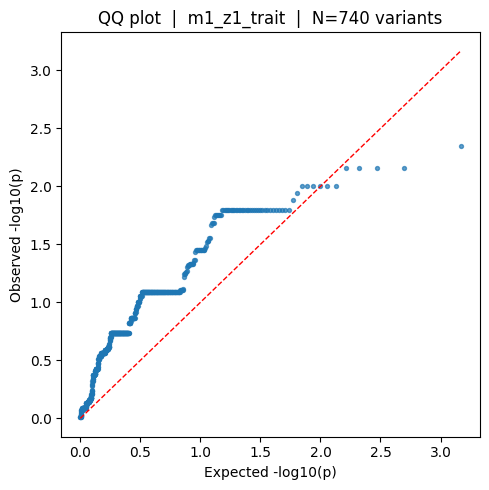

In [36]:
res = pd.read_csv(f"{VCF_FOLDER}/{RESULTS_FILE}.{TRAIT}.glm.linear", sep="\t")
res.columns = [c.lstrip("#") for c in res.columns]
print(f"Total variants tested: {len(res)}")

res = res.dropna(subset=["P"])  # drop variants with missing p-values (e.g. filtered out by plink2)

# ── Attach the imputation INFO score to each variant ──────────────────────────
# plink2's .glm.linear output doesn't carry INFO/INFO (it's a VCF INFO field, not
# something --glm exports), so pull it back from the normalized candidate VCF and
# merge on (CHROM, POS, REF, ALT). Every site in this region is imputed (GSA has
# no directly-genotyped markers in MSH3/PMS2), so INFO is the only signal of how
# trustworthy each call is.
info_out, _ = bcftools(["query", "-f", "%CHROM\t%POS\t%REF\t%ALT\t%INFO/INFO\n", SUBSET_NORM_VCF])
info_scores = pd.DataFrame(
    [line.split("\t") for line in info_out.strip().split("\n")],
    columns=["CHROM", "POS", "REF", "ALT", "INFO"]
)
info_scores["CHROM"] = info_scores["CHROM"].str.replace("chr", "", regex=False)
info_scores["POS"]   = info_scores["POS"].astype(int)
info_scores["INFO"]  = info_scores["INFO"].astype(float)

res["CHROM"] = res["CHROM"].astype(str)
res = res.merge(info_scores, on=["CHROM", "POS", "REF", "ALT"], how="left")

testable = res[
    (res["A1_FREQ"] > 0.10) & (res["A1_FREQ"] < 0.90) & (res["P"].notna()) & (res["INFO"] >= 0.8)   
].copy()
print(f"Testable variants (MAF > 10%, non-NaN p): {len(testable)}")

from statsmodels.stats.multitest import multipletests
testable["padj"] = multipletests(testable["P"], method="fdr_bh")[1]

INFO_CONFIDENT = 0.8  # standard "high-confidence imputation" cutoff; the upstream 0.3
                       # filter only screened out unusable sites, not low-confidence ones

print("\nTop 10 associations:")
top10 = testable.sort_values("P").head(10)
display(top10[["CHROM", "POS", "ID", "REF", "ALT", "A1_FREQ", "BETA", "SE", "P", "padj", "INFO"]])

low_conf_top = top10[top10["INFO"] < INFO_CONFIDENT]
if len(low_conf_top):
    print(f"\nWARNING: {len(low_conf_top)} of the top 10 hit(s) have INFO < {INFO_CONFIDENT} "
          f"(borderline/low-confidence imputation) -- treat with caution until validated "
          f"independently (e.g. against WGS genotypes for overlapping donors):")
    print(low_conf_top[["ID", "P", "INFO"]].to_string(index=False))

p_vals   = testable["P"].sort_values().values
n        = len(p_vals)
expected = -np.log10((np.arange(1, n + 1) - 0.5) / n)
observed = -np.log10(p_vals)

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(expected, observed, s=8, alpha=0.7)
ax.plot([0, expected.max()], [0, expected.max()], "r--", lw=1)
ax.set_xlabel("Expected -log10(p)")
ax.set_ylabel("Observed -log10(p)")
ax.set_title(f"QQ plot  |  {TRAIT}  |  N={n} variants")
plt.tight_layout(); plt.show()


## Follow-up on the top hit

Unlike the WGS notebook (which hardcoded its specific top SNP, `rs245013` at `chr5:80751257`), this pulls whatever variant actually comes out on top of *this* GWAS run, since GSA is a different dataset with its own top hit.

Top hit: 7:5963902:C:CA  (chr7:5963902  C>CA)
  BETA=0.847  SE=0.197  P=0.0003426  A1_FREQ=0.107


PLINK v2.0.0-a.6.9LM 64-bit Intel (29 Jan 2025)    cog-genomics.org/plink/2.0/
(C) 2005-2025 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to GSA/subset/plink/geno_dosage.log.
Options in effect:
  --export A
  --out GSA/subset/plink/geno_dosage
  --pfile GSA/subset/plink/candidate_qc
  --snps 7:5963902:C:CA

Start time: Wed Jul 15 20:14:05 2026
314189 MiB RAM detected, ~148827 available; reserving 148763 MiB for main
workspace.
Using up to 48 threads (change this with --threads).
88 samples (0 females, 0 males, 88 ambiguous; 88 founders) loaded from
GSA/subset/plink/candidate_qc.psam.
1138 variants loaded from GSA/subset/plink/candidate_qc.pvar.
Note: No phenotype data present.
--snps: 1 variant remaining.
1 variant remaining after main filters.

--export A pass 1/1: loading... 0writing... 10111213141517181920212223252627282930313234353637383940424344454647485051525354555657596061626364656768697071727375767778798081828485868788899092939495969798done.
--export

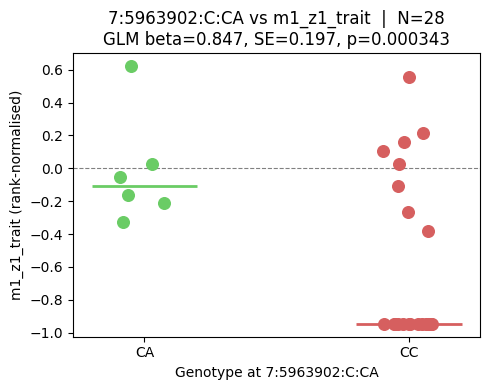


Spearman  rho = -0.432   p = 0.0217
  -> negative association: more 'C' alleles = lower m1_z1_trait
Permutation  p = 0.0226  (|rho| >= 0.432 in 100,000 shuffles)


In [23]:
from scipy import stats

top_hit = testable.sort_values("P").iloc[0]
top_id  = top_hit["ID"]
print(f"Top hit: {top_id}  (chr{top_hit['#CHROM']}:{top_hit['POS']}  {top_hit['REF']}>{top_hit['ALT']})")
print(f"  BETA={top_hit['BETA']:.3f}  SE={top_hit['SE']:.3f}  P={top_hit['P']:.4g}  A1_FREQ={top_hit['A1_FREQ']:.3f}")

DOSAGE_FILE = "GSA/subset/plink/geno_dosage"
plink2(["--pfile", f"{SUBSET_PGEN}_qc", "--snps", top_id, "--export", "A", "--out", DOSAGE_FILE])

geno = pd.read_csv(f"{VCF_FOLDER}/{DOSAGE_FILE}.raw", sep="\t")
snp_col = [c for c in geno.columns if c not in ("FID", "IID", "PAT", "MAT", "SEX", "PHENOTYPE")][0]
a1 = snp_col.split("_")[-1]
print(f"\nSNP column: {snp_col}  ->  counting copies of '{a1}' allele")

geno = geno[["IID", snp_col]].rename(columns={"IID": "original_donor_id", snp_col: "dosage"})
df = df_meta_diseased.merge(geno, on="original_donor_id", how="inner").dropna(subset=["dosage"])
df["dosage"] = df["dosage"].astype(int)
print(f"{len(df)} donors after merge")

other = "C" if a1 == "A" else "A"
label_map = {0: f"{other}{other}", 1: f"{a1}{other}", 2: f"{a1}{a1}"}
df["genotype"] = df["dosage"].map(label_map)
print(df[["original_donor_id", "genotype", "dosage", "m1_z1_trait"]].to_string(index=False))

fig, ax = plt.subplots(figsize=(5, 4))
groups = sorted(df["dosage"].unique())
palette = {0: "#4878CF", 1: "#6ACC65", 2: "#D65F5F"}
for g in groups:
    sub = df[df["dosage"] == g]["m1_z1_trait"]
    x = g + np.random.uniform(-0.1, 0.1, size=len(sub))
    ax.scatter(x, sub, color=palette.get(g, "gray"), s=70, zorder=3, label=label_map.get(g, str(g)))
    ax.hlines(sub.median(), g - 0.2, g + 0.2, color=palette.get(g, "gray"), linewidth=2, zorder=4)
ax.set_xticks(groups)
ax.set_xticklabels([label_map.get(g, str(g)) for g in groups])
ax.set_xlabel(f"Genotype at {top_id}")
ax.set_ylabel("m1_z1_trait (rank-normalised)")
ax.set_title(f"{top_id} vs m1_z1_trait  |  N={len(df)}\n"
             f"GLM beta={top_hit['BETA']:.3f}, SE={top_hit['SE']:.3f}, p={top_hit['P']:.3g}")
ax.axhline(0, color="grey", linewidth=0.8, linestyle="--")
plt.tight_layout(); plt.show()

rho, p_spear = stats.spearmanr(df["dosage"], df["m1_z1_trait"])
print(f"\nSpearman  rho = {rho:+.3f}   p = {p_spear:.4f}")
print(f"  -> {'positive' if rho > 0 else 'negative'} association: "
      f"more '{a1}' alleles = {'higher' if rho > 0 else 'lower'} m1_z1_trait")

np.random.seed(42)
n_perm = 100_000
obs = abs(rho)
null_rhos = [
    abs(stats.spearmanr(np.random.permutation(df["dosage"]), df["m1_z1_trait"])[0])
    for _ in range(n_perm)
]
p_perm = np.mean(np.array(null_rhos) >= obs)
print(f"Permutation  p = {p_perm:.4f}  (|rho| >= {obs:.3f} in {n_perm:,} shuffles)")


### Clinical variable correlations

A) Genotype (dosage) vs clinical variables
  age_of_onset          N=23  rho=-0.406  p=0.0543  ~
  age_of_death          N=28  rho=-0.427  p=0.0235  *
  disease_duration      N=23  rho=-0.120  p=0.5863  
  repeat_length         N=28  rho=+0.254  p=0.1916  

B) Trait (m1_z1_trait) vs clinical variables
  age_of_onset          N=23  rho=-0.042  p=0.8482  
  age_of_death          N=28  rho=-0.111  p=0.5741  
  disease_duration      N=23  rho=-0.318  p=0.1393  
  repeat_length         N=28  rho=+0.317  p=0.1008  


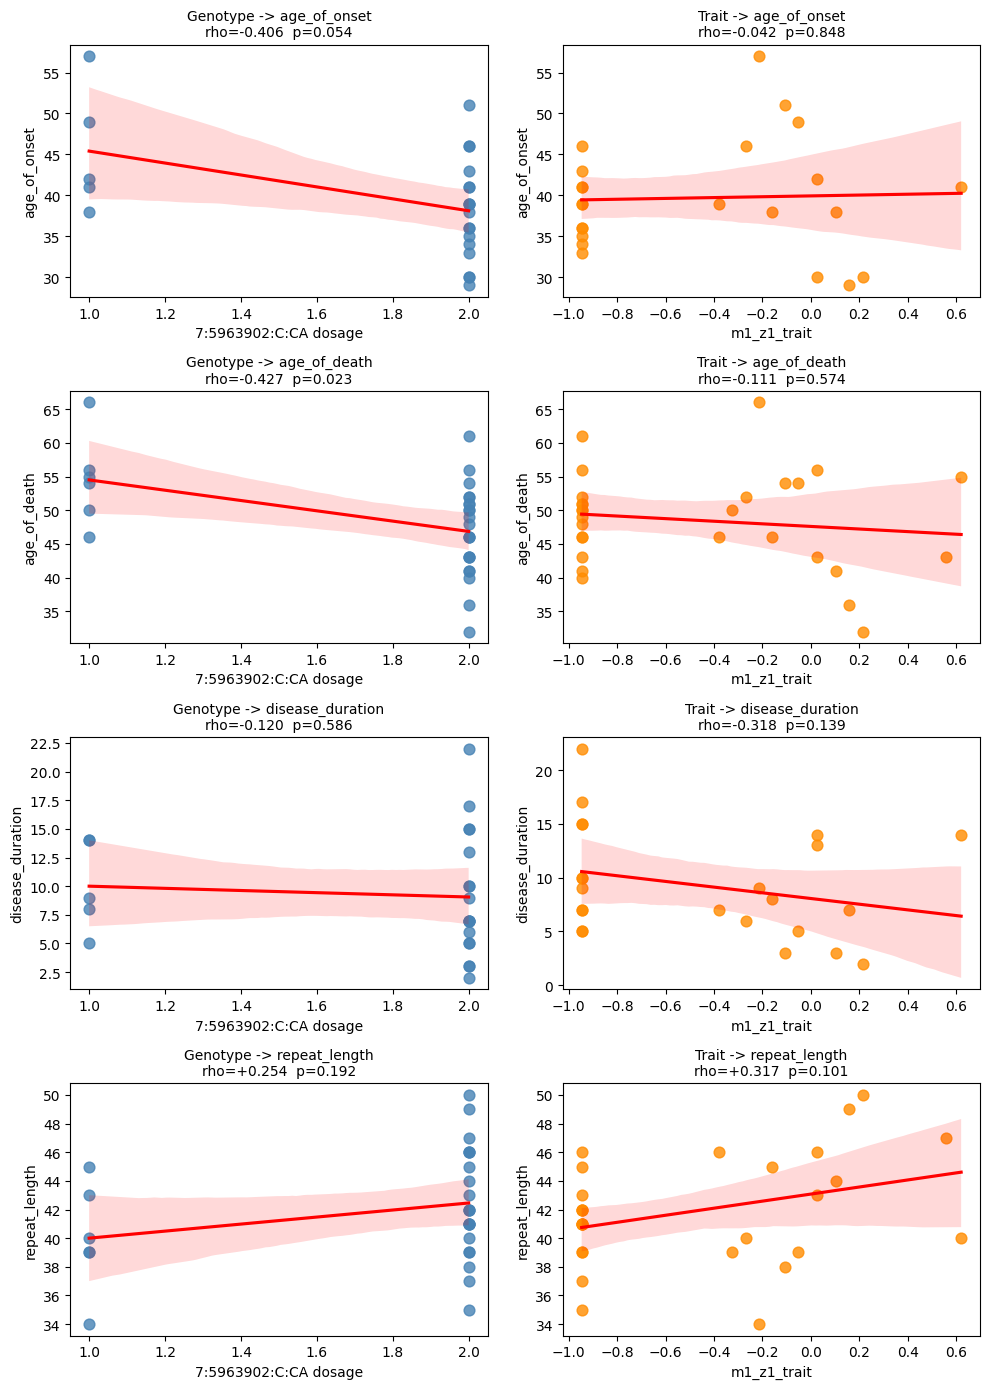

In [17]:
clinical_vars = ["age_of_onset", "age_of_death", "disease_duration", "repeat_length"]

df_clin = df.copy()
for v in clinical_vars:
    df_clin[v] = pd.to_numeric(df_clin[v], errors="coerce")

print("=" * 55)
print("A) Genotype (dosage) vs clinical variables")
print("=" * 55)
results_geno = []
for v in clinical_vars:
    sub = df_clin[["dosage", v]].dropna()
    if len(sub) < 5:
        print(f"  {v}: too few values ({len(sub)}), skip")
        continue
    rho, p = stats.spearmanr(sub["dosage"], sub[v])
    results_geno.append({"variable": v, "N": len(sub), "rho": rho, "p": p})
    sig = "*" if p < 0.05 else ("~" if p < 0.10 else "")
    print(f"  {v:<20}  N={len(sub)}  rho={rho:+.3f}  p={p:.4f}  {sig}")

print()
print("=" * 55)
print("B) Trait (m1_z1_trait) vs clinical variables")
print("=" * 55)
results_trait = []
for v in clinical_vars:
    sub = df_clin[["m1_z1_trait", v]].dropna()
    if len(sub) < 5:
        continue
    rho, p = stats.spearmanr(sub["m1_z1_trait"], sub[v])
    results_trait.append({"variable": v, "N": len(sub), "rho": rho, "p": p})
    sig = "*" if p < 0.05 else ("~" if p < 0.10 else "")
    print(f"  {v:<20}  N={len(sub)}  rho={rho:+.3f}  p={p:.4f}  {sig}")

fig, axes = plt.subplots(len(clinical_vars), 2, figsize=(10, 3.5 * len(clinical_vars)))
for i, v in enumerate(clinical_vars):
    sub = df_clin[["dosage", "m1_z1_trait", v]].dropna()

    ax = axes[i, 0]
    sns.regplot(data=sub, x="dosage", y=v, ax=ax,
                scatter_kws={"s": 60, "color": "steelblue"}, line_kws={"color": "red"})
    rho_g = next((r["rho"] for r in results_geno if r["variable"] == v), np.nan)
    p_g   = next((r["p"]   for r in results_geno if r["variable"] == v), np.nan)
    ax.set_xlabel(f"{top_id} dosage"); ax.set_ylabel(v)
    ax.set_title(f"Genotype -> {v}\nrho={rho_g:+.3f}  p={p_g:.3f}", fontsize=10)

    ax2 = axes[i, 1]
    sns.regplot(data=sub, x="m1_z1_trait", y=v, ax=ax2,
                scatter_kws={"s": 60, "color": "darkorange"}, line_kws={"color": "red"})
    rho_t = next((r["rho"] for r in results_trait if r["variable"] == v), np.nan)
    p_t   = next((r["p"]   for r in results_trait if r["variable"] == v), np.nan)
    ax2.set_xlabel("m1_z1_trait"); ax2.set_ylabel(v)
    ax2.set_title(f"Trait -> {v}\nrho={rho_t:+.3f}  p={p_t:.3f}", fontsize=10)

plt.tight_layout()
plt.show()


### rsID lookup for the top hit

Dynamic version of the WGS notebook's cell 40 (which looked up one hardcoded variant).

In [ ]:
import requests

def get_rsid(chrom, pos, ref, alt):
    hgvs = f"chr{chrom}:g.{pos}{ref}>{alt}"
    url = f"https://myvariant.info/v1/variant/{hgvs}?fields=dbsnp.rsid"
    response = requests.get(url)
    if response.status_code == 200:
        data = response.json()
        return data.get("dbsnp", {}).get("rsid", "No rsID found")
    return "Variant not found or query failed"

chrom_bare = str(top_hit["#CHROM"]).replace("chr", "")
rs_name = get_rsid(chrom_bare, top_hit["POS"], top_hit["REF"], top_hit["ALT"])
print(f"Top hit {top_id} -> rsID: {rs_name}")
